In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 모델링
from sklearn import linear_model
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 다중공선성 검사
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 모델 평가
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [ ]:
# 사용할 데이터셋 불러오기
df = pd.read_csv("/content/drive/MyDrive/폭염 대비 제주도 여름철 전력 수요 예측/최종 데이터/final_data.csv")

In [ ]:
# 그래프의 배경을 설정
sns.set_style('darkgrid')

### 데이터 탐색

변수 의미<br>
- power_demand_MWh: 제주도 시간별 전력 수요량(MWh)
- is_weekend: 주말 여부
- hour_sin: 시간대 순환 특성(sin 변환)
- hour_cos: 시간대 순환 특성(cos 변환)
- resident_pop: 거주 인구 수
- working_pop: 근무 인구 수
- visitor_pop: 방문 인구 수
- total_visitors: 전체 관광객 수
- renewable_energy_mwh: 재생에너지 발전량(MWh)
- TA_mean: 평균 기온
- HM_mean: 평균 습도
- HM_max: 최고 습도
- tropical_night: 열대야 여부
- CDD: 냉방도일
- power_1h: 1시간 전 전력 수요
- power_24h: 24시간 전 전력 수요
- power_48h: 48시간 전 전력 수요
- power_168h: 168시간 전 전력 수요

In [ ]:
# 데이터 구성 확인
df.head()

,power_demand_MWh,is_weekend,hour_sin,hour_cos,resident_pop,working_pop,visitor_pop,total_visitors,renewable_energy_mwh,TA_mean,HM_mean,HM_max,tropical_night,CDD,power_1h,power_24h,power_48h,power_168h
0,537.796,0,0.000000,1.000000,137664.0,17839.0,68980.0,32603.0,140.68,20.125,84.25,94.0,0,0.0,581.418,554.165,546.645,565.718
1,509.852,0,0.258819,0.965926,137664.0,17839.0,68980.0,32603.0,127.56,20.050,85.75,96.0,0,0.0,537.796,520.870,513.702,532.895
2,488.905,0,0.500000,0.866025,137664.0,17839.0,68980.0,32603.0,126.70,19.850,85.50,96.0,0,0.0,509.852,502.563,493.970,511.896
3,479.200,0,0.707107,0.707107,137664.0,17839.0,68980.0,32603.0,121.12,19.775,85.75,98.0,0,0.0,488.905,492.517,482.880,500.607
4,480.823,0,0.866025,0.500000,137664.0,17839.0,68980.0,32603.0,109.05,19.825,87.50,99.0,0,0.0,479.200,492.295,479.191,499.947


In [ ]:
# 데이터셋의 기본 정보 파악
df.shape

(8928, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   power_demand_MWh      8928 non-null   float64
 1   is_weekend            8928 non-null   int64  
 2   hour_sin              8928 non-null   float64
 3   hour_cos              8928 non-null   float64
 4   resident_pop          8928 non-null   float64
 5   working_pop           8928 non-null   float64
 6   visitor_pop           8928 non-null   float64
 7   total_visitors        8928 non-null   float64
 8   renewable_energy_mwh  8928 non-null   float64
 9   TA_mean               8928 non-null   float64
 10  HM_mean               8928 non-null   float64
 11  HM_max                8928 non-null   float64
 12  tropical_night        8928 non-null   int64  
 13  CDD                   8928 non-null   float64
 14  power_1h              8928 non-null   float64
 15  power_24h            

str형은 없고 다 int, float형 데이터 <br>
int형 데이터는 0/1로 된 데이터

In [ ]:
# 결측치 확인
df.isnull().sum()

,0
power_demand_MWh,0
is_weekend,0
hour_sin,0
hour_cos,0
resident_pop,0
working_pop,0
visitor_pop,0
total_visitors,0
renewable_energy_mwh,0
TA_mean,0


null값 없음

In [ ]:
# [통계] 수치형 변수만 뽑아서 기본 통계량 확인하기
df.describe()

,power_demand_MWh,is_weekend,hour_sin,hour_cos,resident_pop,working_pop,visitor_pop,total_visitors,renewable_energy_mwh,TA_mean,HM_mean,HM_max,tropical_night,CDD,power_1h,power_24h,power_48h,power_168h
count,8928.000000,8928.000000,8.928000e+03,8.928000e+03,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.00000
mean,803.889321,0.287634,-1.850372e-17,-5.541167e-17,197367.102151,23188.639785,100720.005376,38150.298387,55.381249,27.370271,84.001527,91.685394,0.435484,1.799109,803.880705,803.124404,801.813482,792.58761
std,146.957284,0.452685,7.071464e-01,7.071464e-01,57328.435487,12055.039742,37970.307710,5758.560783,74.210915,2.387358,8.286755,7.757745,0.495848,1.751557,146.968389,147.365871,147.541515,147.48982
min,479.200000,0.000000,-1.000000e+00,-1.000000e+00,70802.000000,6813.000000,25466.000000,19902.000000,0.000000,19.200000,51.500000,62.000000,0.000000,0.000000,479.200000,479.200000,479.191000,479.19100
25%,679.342750,0.000000,-7.071068e-01,-7.071068e-01,152129.750000,14925.000000,71541.500000,34779.500000,0.000000,26.000000,78.250000,87.000000,0.000000,0.000000,679.329250,678.022000,677.240000,669.99800
50%,805.855000,0.000000,6.123234e-17,-6.123234e-17,191344.000000,19897.500000,98363.000000,38174.000000,14.220000,27.375000,85.000000,94.000000,0.000000,1.375000,805.855000,804.522000,802.352500,787.78650
75%,918.353000,1.000000,7.071068e-01,7.071068e-01,233193.500000,28375.500000,123222.000000,42438.000000,97.720000,28.925000,90.500000,98.000000,1.000000,2.925000,918.353000,918.248750,916.847250,908.86125
max,1178.631000,1.000000,1.000000e+00,1.000000e+00,361909.000000,88225.000000,263225.000000,50652.000000,346.990000,33.225000,99.250000,100.000000,1.000000,7.225000,1178.631000,1178.631000,1178.631000,1178.63100


In [ ]:
df.columns

Index(['power_demand_MWh', 'is_weekend', 'hour_sin', 'hour_cos',
       'resident_pop', 'working_pop', 'visitor_pop', 'total_visitors',
       'renewable_energy_mwh', 'TA_mean', 'HM_mean', 'HM_max',
       'tropical_night', 'CDD', 'power_1h', 'power_24h', 'power_48h',
       'power_168h'],
      dtype='object')

/tmp/ipykernel_2715/3788001554.py:26: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[numerical_columns].hist(ax=ax)


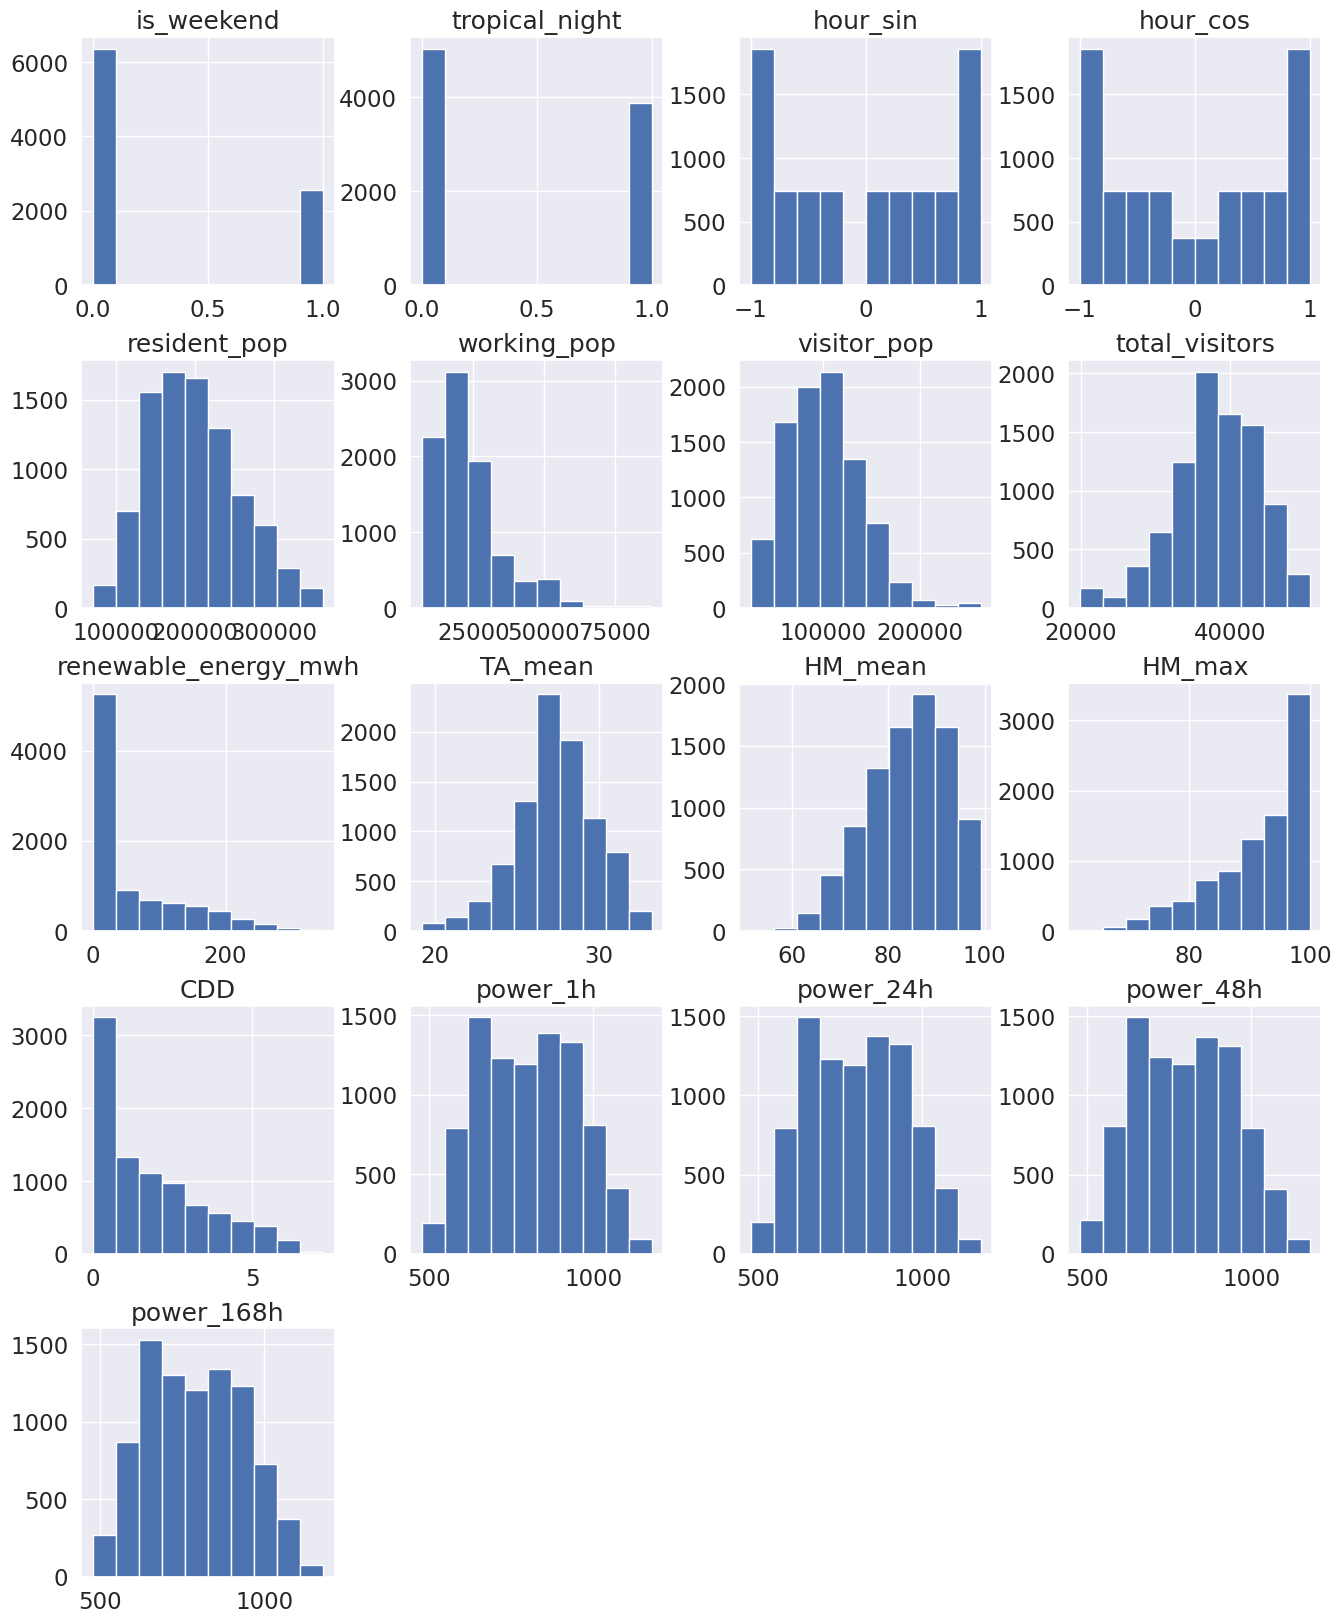

In [ ]:
# 독립 변수 탐색
# numerical features (except str data type, power_demand_MWh(종속 변수))
numerical_columns = [
    'is_weekend',             # int64
    'tropical_night',         # int64
    'hour_sin',               # float64
    'hour_cos',               # float64
    'resident_pop',           # float64
    'working_pop',            # float64
    'visitor_pop',            # float64
    'total_visitors',         # float64
    'renewable_energy_mwh',   # float64
    'TA_mean',                # float64
    'HM_mean',                 # float64
    'HM_max',                 # float64
    'CDD',                    # float64
    'power_1h',               # float64
    'power_24h',               # float64
    'power_48h',              # float64
    'power_168h'              # float64
]

# 수치형 독립 변수 분포 시각화
fig = plt.figure(figsize = (16, 20))
ax = fig.gca()
df[numerical_columns].hist(ax=ax)
plt.show()

In [ ]:
cols =  [
    'power_demand_MWh',       # float64
    'is_weekend',             # int64
    'tropical_night',         # int64
    'hour_sin',               # float64
    'hour_cos',               # float64
    'resident_pop',           # float64
    'working_pop',            # float64
    'visitor_pop',            # float64
    'total_visitors',         # float64
    'renewable_energy_mwh',   # float64
    'TA_mean',                # float64
    'HM_mean',                 # float64
    'HM_max',                 # float64
    'CDD',                    # float64
    'power_1h',               # float64
    'power_24h',               # float64
    'power_48h',              # float64
    'power_168h'              # float64
]


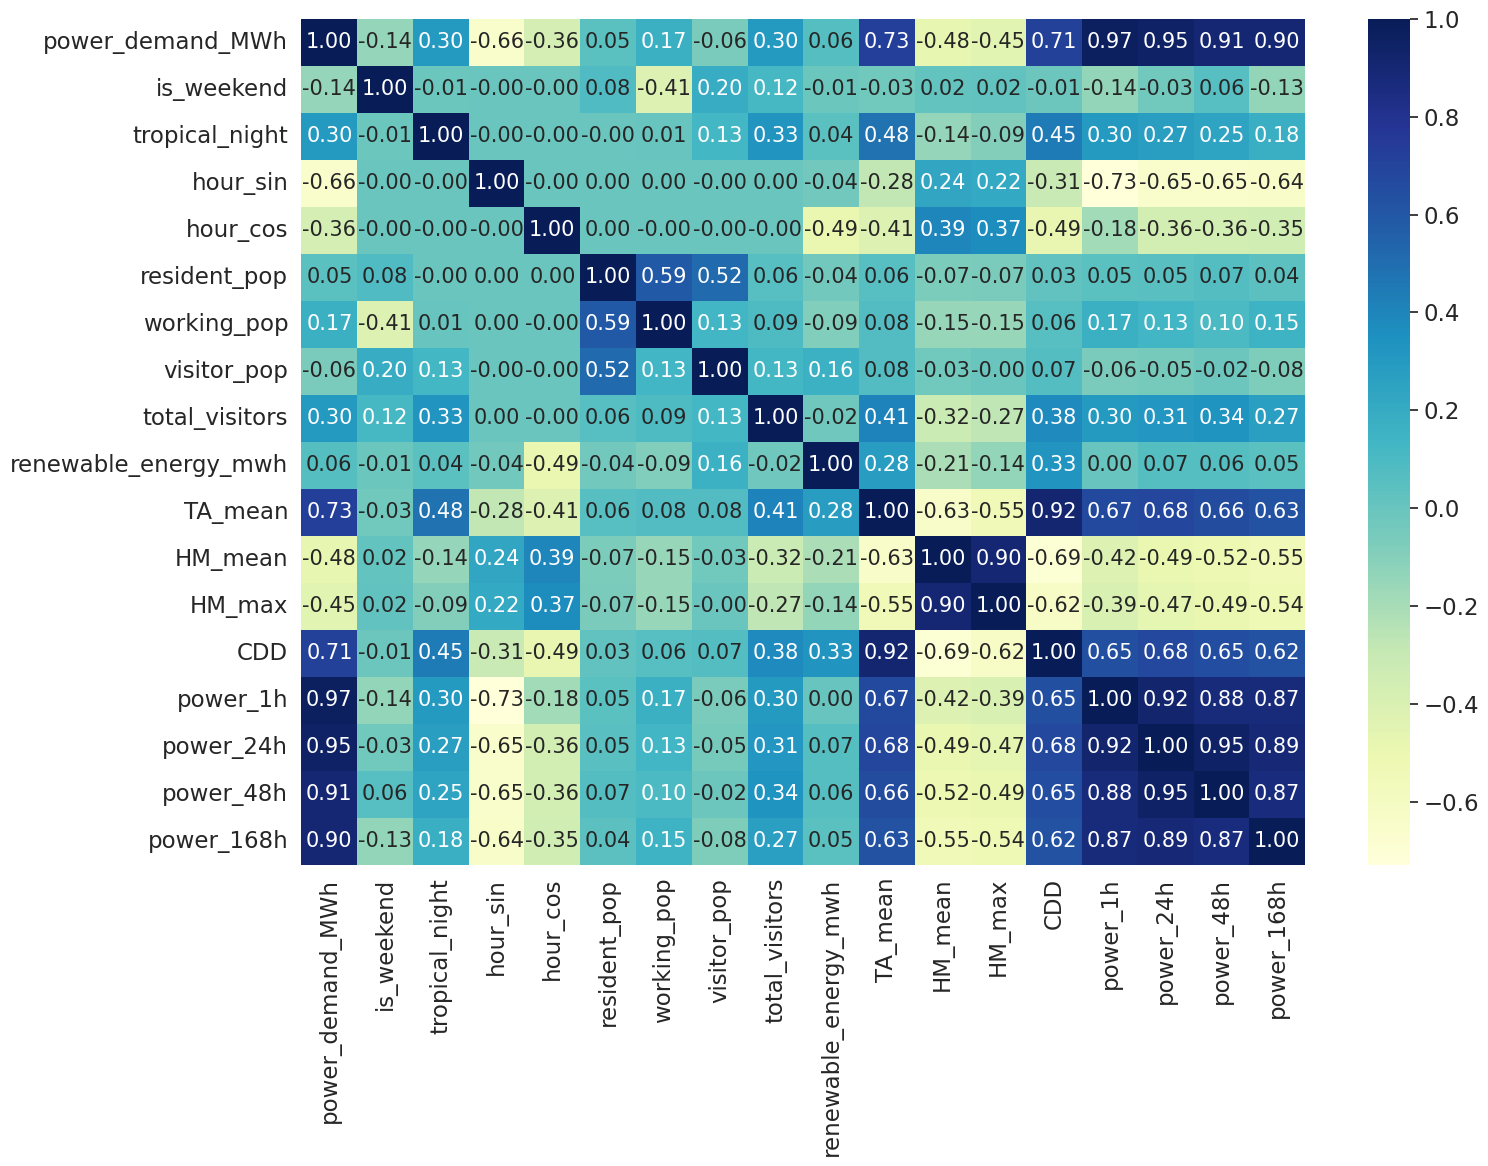

In [ ]:
corr = df[cols].corr(method = 'pearson')
corr

# 히트맵(heatmap)으로 상관관계 시각화
fig = plt.figure(figsize = (16, 12))
ax = fig.gca()

sns.set(font_scale = 1.5)
heatmap = sns.heatmap(corr.values, annot = True, fmt='.2f',
                      annot_kws={'size':15},
                      yticklabels = cols, xticklabels = cols,
                      ax=ax, cmap = "YlGnBu")
plt.tight_layout()

plt.show()

### 모델링

In [ ]:
# 시계열 기반 Train/Test 분할
# 2025년 7~8월 = 62일 × 24시간 = 1488행
test_n = 62 * 24

train_df = df.iloc[:-test_n].copy()  # 2020~2024
test_df = df.iloc[-test_n:].copy()   # 2025

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

전체 행 수: 8928
24로 나눈 나머지: 0
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5]
[18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
hour 순서 정상 여부: True


In [ ]:
target_col = "power_demand_MWh"

X_train = train_df[numerical_columns].copy()
y_train = train_df[target_col].copy()

X_test = test_df[numerical_columns].copy()
y_test = test_df[target_col].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7440, 17)
X_test: (1488, 17)
y_train: (7440,)
y_test: (1488,)


In [ ]:
# 수치형 독립 변수 표준화
# 표준화
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

/tmp/ipykernel_2715/3776135076.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  X_train[numerical_columns].hist(ax=ax)


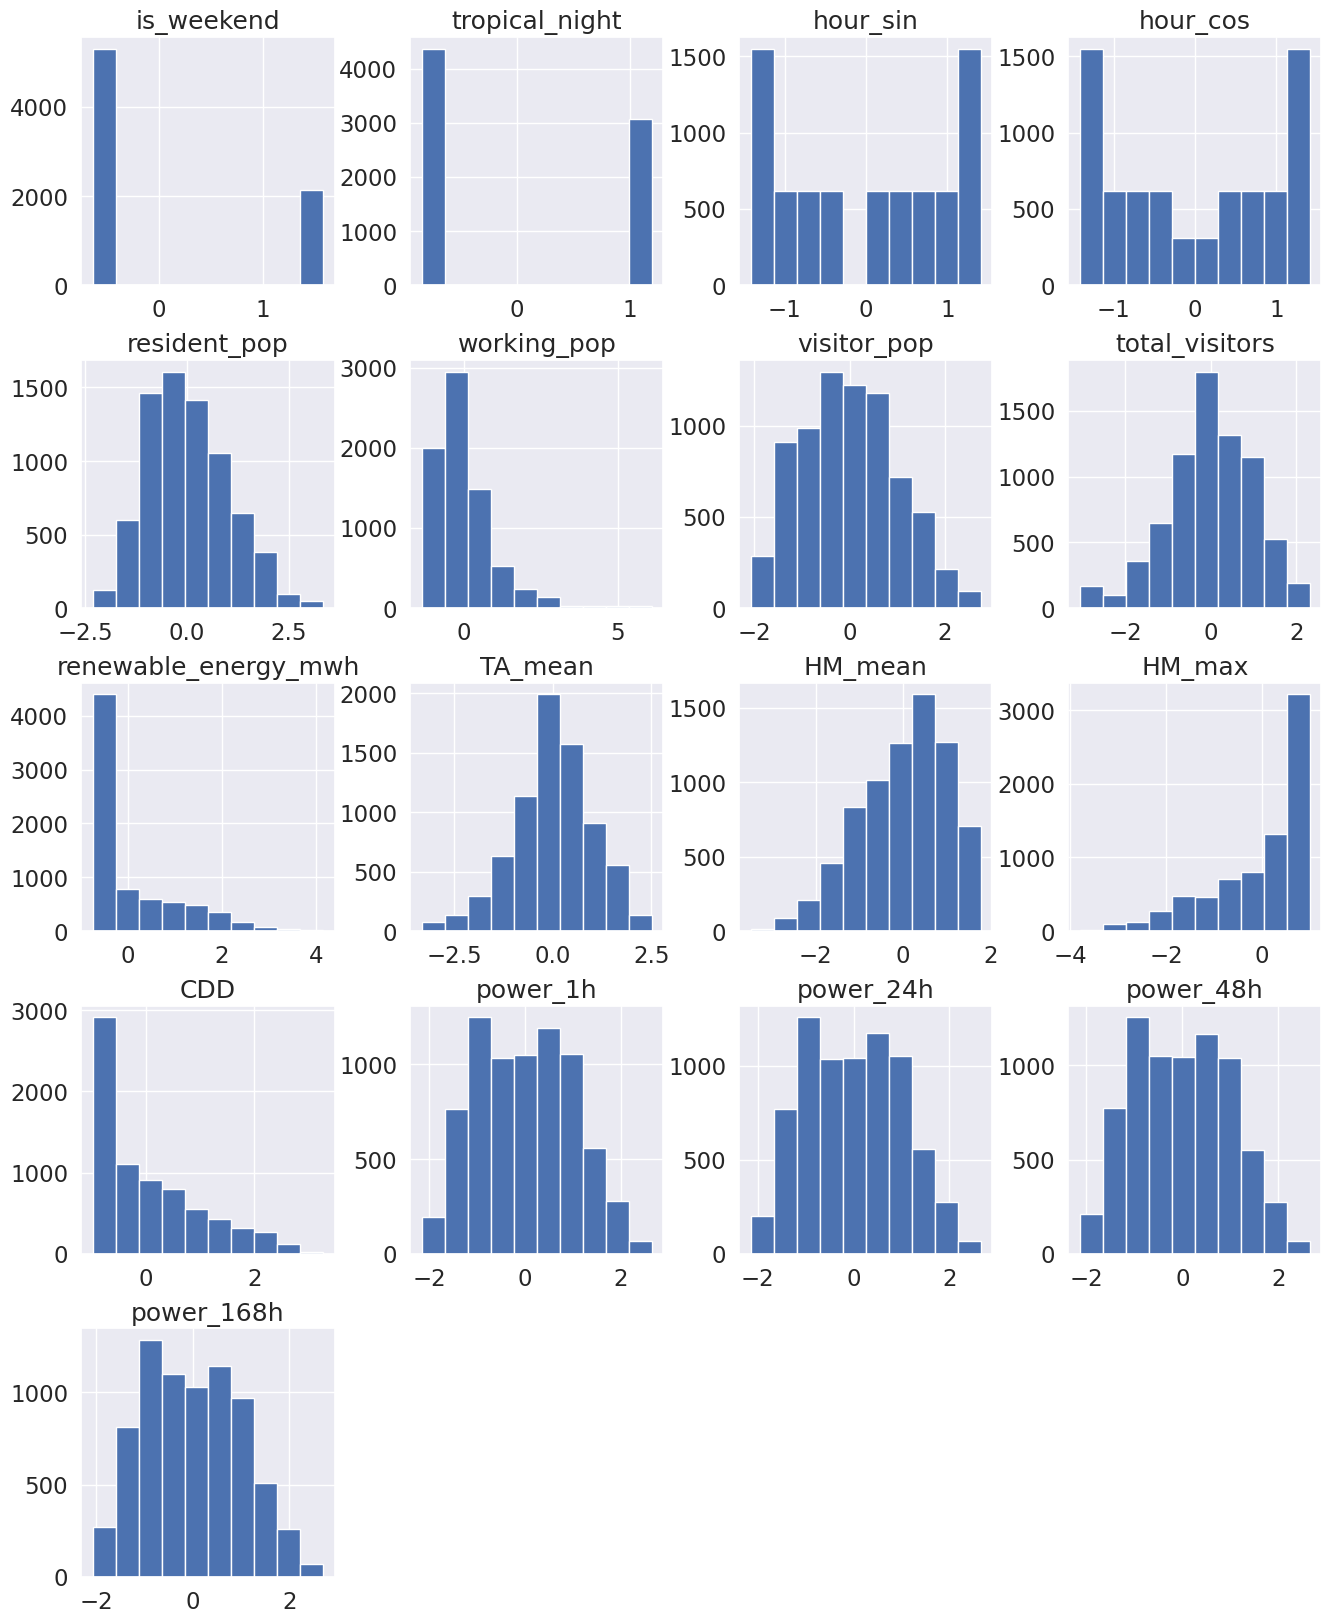

In [ ]:
# 독립 변수 탐색
fig = plt.figure(figsize = (16, 20))
ax = fig.gca()
X_train[numerical_columns].hist(ax=ax)
plt.show()

In [ ]:
X_train[numerical_columns].head()

,is_weekend,tropical_night,hour_sin,hour_cos,resident_pop,working_pop,visitor_pop,total_visitors,renewable_energy_mwh,TA_mean,HM_mean,HM_max,CDD,power_1h,power_24h,power_48h,power_168h
0,-0.634598,-0.838628,2.363580e-17,1.414214,-1.013592,-0.346718,-0.901793,-0.832176,1.239268,-2.932870,-0.088540,0.198094,-0.98445,-1.452854,-1.630545,-1.672295,-1.480907
1,-0.634598,-0.838628,3.660254e-01,1.366025,-1.013592,-0.346718,-0.901793,-0.832176,1.054353,-2.964056,0.098158,0.464780,-0.98445,-1.753115,-1.859158,-1.898219,-1.704886
2,-0.634598,-0.838628,7.071068e-01,1.224745,-1.013592,-0.346718,-0.901793,-0.832176,1.042232,-3.047220,0.067041,0.464780,-0.98445,-1.945460,-1.984859,-2.033541,-1.848180
3,-0.634598,-0.838628,1.000000e+00,1.000000,-1.013592,-0.346718,-0.901793,-0.832176,0.963587,-3.078406,0.098158,0.731467,-0.98445,-2.089643,-2.053837,-2.109596,-1.925214
4,-0.634598,-0.838628,1.224745e+00,0.707107,-1.013592,-0.346718,-0.901793,-0.832176,0.793470,-3.057615,0.315971,0.864811,-0.98445,-2.156444,-2.055362,-2.134895,-1.929718


In [ ]:
y_train

,power_demand_MWh
0,537.796
1,509.852
2,488.905
3,479.200
4,480.823
...,...
7435,969.650
7436,935.302
7437,880.648
7438,825.065


In [ ]:
X_train

,is_weekend,tropical_night,hour_sin,hour_cos,resident_pop,working_pop,visitor_pop,total_visitors,renewable_energy_mwh,TA_mean,HM_mean,HM_max,CDD,power_1h,power_24h,power_48h,power_168h
0,-0.634598,-0.838628,2.363580e-17,1.414214,-1.013592,-0.346718,-0.901793,-0.832176,1.239268,-2.932870,-0.088540,0.198094,-0.984450,-1.452854,-1.630545,-1.672295,-1.480907
1,-0.634598,-0.838628,3.660254e-01,1.366025,-1.013592,-0.346718,-0.901793,-0.832176,1.054353,-2.964056,0.098158,0.464780,-0.984450,-1.753115,-1.859158,-1.898219,-1.704886
2,-0.634598,-0.838628,7.071068e-01,1.224745,-1.013592,-0.346718,-0.901793,-0.832176,1.042232,-3.047220,0.067041,0.464780,-0.984450,-1.945460,-1.984859,-2.033541,-1.848180
3,-0.634598,-0.838628,1.000000e+00,1.000000,-1.013592,-0.346718,-0.901793,-0.832176,0.963587,-3.078406,0.098158,0.731467,-0.984450,-2.089643,-2.053837,-2.109596,-1.925214
4,-0.634598,-0.838628,1.224745e+00,0.707107,-1.013592,-0.346718,-0.901793,-0.832176,0.793470,-3.057615,0.315971,0.864811,-0.984450,-2.156444,-2.055362,-2.134895,-1.929718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7435,1.575800,-0.838628,-1.366025e+00,0.366025,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,0.216950,-1.737701,-1.935400,0.016859,1.225831,1.705877,1.853661,1.767096
7436,1.575800,-0.838628,-1.224745e+00,0.707107,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,-0.063727,-1.488771,-2.068743,-0.380719,1.219436,1.455505,1.627806,1.545806
7437,1.575800,-0.838628,-1.000000e+00,1.000000,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,-0.302822,-1.488771,-1.802057,-0.719398,0.983011,1.058201,1.233320,1.187418
7438,1.575800,-0.838628,-7.071068e-01,1.224745,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,-0.593895,-1.551004,-1.935400,-0.984450,0.606815,0.648628,0.797439,0.771143


In [ ]:
# 다중공선성 검사 (VIF)
vif = pd.DataFrame()
vif['features'] = X_train.columns
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i)
                    for i in range(X_train.shape[1])]

vif.sort_values(by="VIF Factor", ascending=False).round(1)

,features,VIF Factor
14,power_24h,15.9
13,power_1h,15.0
15,power_48h,11.7
12,CDD,7.8
16,power_168h,7.4
9,TA_mean,7.4
10,HM_mean,6.7
11,HM_max,5.8
2,hour_sin,3.8
3,hour_cos,2.3


VIF 높은 것들이 많음

In [ ]:
# 'power_168h','power_48h' 제외 해보기
X_train_dropped = X_train.drop(columns=['power_168h','power_48h'])

# 제외된 데이터(X_train_dropped)로 VIF 다시 계산
vif_new = pd.DataFrame()
vif_new['features'] = X_train_dropped.columns
vif_new["VIF Factor"] = [variance_inflation_factor(X_train_dropped.values, i)
                        for i in range(X_train_dropped.shape[1])]

# 내림차순 정렬 및 반올림 출력
vif_new.sort_values(by="VIF Factor", ascending=False).round(1)


,features,VIF Factor
13,power_1h,13.0
14,power_24h,9.3
12,CDD,7.7
9,TA_mean,7.3
10,HM_mean,6.7
11,HM_max,5.6
2,hour_sin,3.7
5,working_pop,2.3
3,hour_cos,2.3
4,resident_pop,2.3


아직도 VIF 높음

In [ ]:
# 'power_168h','power_24h' 제외 해보기
X_train_dropped = X_train.drop(columns=['power_168h','power_24h'])

# 제외된 데이터(X_train_dropped)로 VIF 다시 계산
vif_new = pd.DataFrame()
vif_new['features'] = X_train_dropped.columns
vif_new["VIF Factor"] = [variance_inflation_factor(X_train_dropped.values, i)
                        for i in range(X_train_dropped.shape[1])]

# 내림차순 정렬 및 반올림 출력
vif_new.sort_values(by="VIF Factor", ascending=False).round(1)

,features,VIF Factor
13,power_1h,10.1
12,CDD,7.7
9,TA_mean,7.4
14,power_48h,6.8
10,HM_mean,6.7
11,HM_max,5.6
2,hour_sin,3.8
5,working_pop,2.3
4,resident_pop,2.3
3,hour_cos,2.1


power_1h의 VIF가 10.1로 여전히 높지만, 1시간 전 전력 수요는 현재 수요를 예측하는 데 가장 핵심적인 변수이므로 유지한다.<br>
나머지 변수들은 VIF 10 미만으로 다중공선성이 수용 가능한 수준이다.

In [ ]:
# 컬럼 삭제 (원본 데이터 복사본 생성)
X_train_drop = X_train.drop(columns=['power_168h','power_24h'])
X_test_drop = X_test.drop(columns=['power_168h','power_24h'])

In [ ]:
# 덮어쓰기
X_train = X_train_drop
X_test = X_test_drop

In [ ]:
# 인덱스 재정렬
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

### Linear Regression

In [ ]:
# train 데이터로 선형 회귀 모델 학습
lr = linear_model.LinearRegression()
model = lr.fit(X_train, y_train)

# test 데이터로 예측
pred_test = lr.predict(X_test)

In [ ]:
# 회귀 계수
coefs = pd.DataFrame(zip(X_train.columns, lr.coef_),
                    columns=['feature', 'coefficients'])
coefs

# 회귀 계수를 크기 순서대로 나열
coefs_new = coefs.reindex(coefs.coefficients.abs().
                          sort_values(ascending=False).index)
coefs_new

,feature,coefficients
13,power_1h,113.923836
3,hour_cos,-25.360800
14,power_48h,19.175384
8,renewable_energy_mwh,-7.220534
12,CDD,6.011955
0,is_weekend,-5.503803
9,TA_mean,4.514176
11,HM_max,2.994319
10,HM_mean,2.658384
2,hour_sin,1.526763


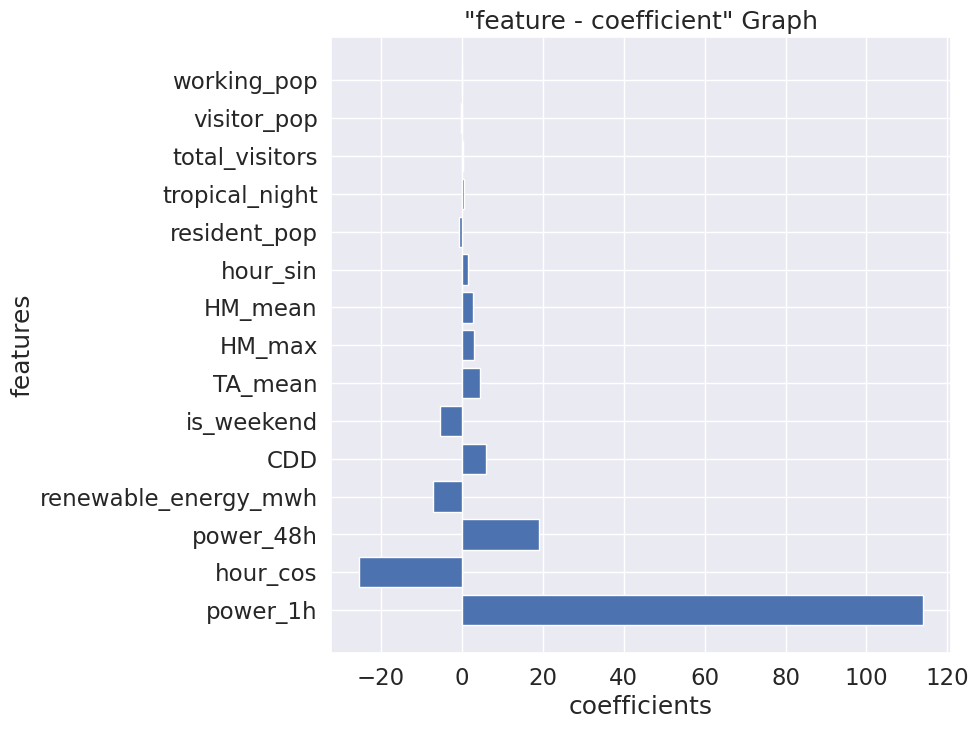

In [ ]:
# 회귀 계수 시각화
plt.figure(figsize = (8, 8))

plt.barh(coefs_new['feature'], coefs_new['coefficients'])
plt.title('"feature - coefficient" Graph')
plt.xlabel('coefficients')
plt.ylabel('features')
plt.show()

In [ ]:
# 회귀 분석 모형 수식 간단하게 만들기 위해 독립변수 데이터에 상수항 추가
X_train2 = sm.add_constant(X_train)

# OLS
model2 = sm.OLS(y_train, X_train2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       power_demand_MWh   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                 2.128e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:52:47   Log-Likelihood:                -33521.
No. Observations:                7440   AIC:                         6.707e+04
Df Residuals:                    7424   BIC:                         6.718e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  792.5008      0.254   3117.892      0.000     792.003     792.999
is_weekend              -5.5038      0.341    -16.135      0.000      -6.172      -4.835
tropical_night           0.5996      0.336      1.784      0.074      -0.059       1.258
hour_sin                 1.5268      0.496      3.077      0.002       0.554       2.500
hour_cos               -25.3608      0.373    -68.057      0.000     -26.091     -24.630
resident_pop            -0.6160      0.382     -1.615      0.106      -1.364       0.132
working_pop              0.1116      0.387      0.288      0.773      -0.647       0.870
visitor_pop             -0.1440      0.318     -0.453      0.650      -0.767       0.479
total_visitors           0.2918      0.312      0.936      0.349      -0.320       0.903
renewable_energy_mwh    -7.2205      0.327    -22.052      0.000      -7.862      -6.579
TA_mean                  4.5142      0.689      6.550      0.000       3.163       5.865
HM_mean                  2.6584      0.658      4.041      0.000       1.369       3.948
HM_max                   2.9943      0.601      4.982      0.000       1.816       4.172
CDD                      6.0120      0.707      8.502      0.000       4.626       7.398
power_1h               113.9238      0.808    140.912      0.000     112.339     115.509
power_48h               19.1754      0.662     28.951      0.000      17.877      20.474
==============================================================================
Omnibus:                       87.897   Durbin-Watson:                   0.566
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.270
Skew:                           0.224   Prob(JB):                     4.58e-22
Kurtosis:                       3.341   Cond. No.                         8.82
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### OLS 결과 해석

- **R² = 0.977**: 독립변수들이 전력 수요 변동의 97.7%를 설명함
- **유의한 변수 (p < 0.05)**: power_1h, hour_cos, power_48h, renewable_energy_mwh, is_weekend, CDD, TA_mean, HM_mean, HM_max 등 대부분의 변수가 통계적으로 유의함
- **비유의 변수 (p > 0.05)**: resident_pop, working_pop, visitor_pop, total_visitors, tropical_night 등 일부 변수의 p-value가 높지만, 도메인 관점에서 인구 및 관광객 변수는 제주도 여름철 전력 수요의 구조적 증가 추세를 반영하므로 모델에 유지함
- 비유의 변수를 제거하더라도 R²의 개선은 미미할 것으로 예상되며, Adj. R²가 R²와 거의 동일하므로 과적합 가능성도 낮음

In [ ]:
# 예측값과 실제값 비교
df_pred1 = pd.DataFrame({'actual': y_test, 'prediction': pred_test})
df_pred1 = df_pred1.sort_values(by='actual').reset_index(drop=True)
df_pred1.head()

,actual,prediction
0,562.533,566.302489
1,565.407,573.434209
2,576.758,573.861648
3,581.504,589.364416
4,584.632,588.510769


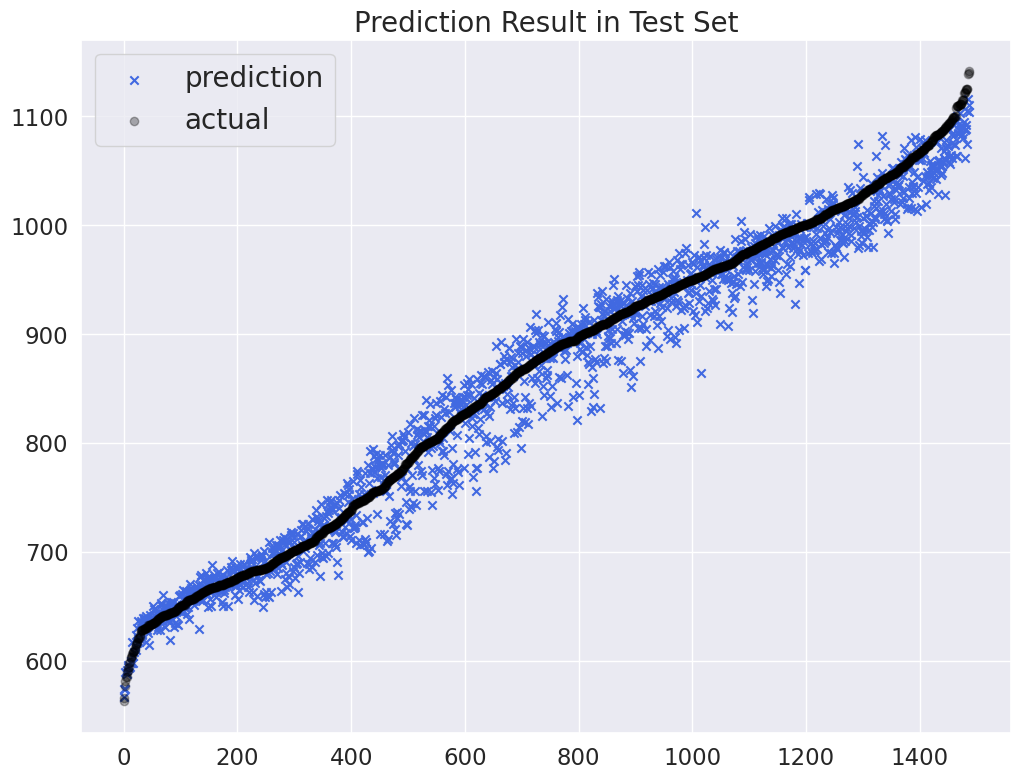

In [ ]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(12, 9))
plt.scatter(df_pred1.index, df_pred1['prediction'], marker='x', color='royalblue')
plt.scatter(df_pred1.index, df_pred1['actual'], alpha=0.3, marker='o', color='black')
plt.title("Prediction Result in Test Set", fontsize=20)
plt.legend(['prediction', 'actual'], fontsize=20)
plt.show()

In [ ]:
# 모델 성능 평가
pred_train = lr.predict(X_train)

print('R-Squared')
print("train: ", lr.score(X_train, y_train)) # training set
print("test: ", lr.score(X_test, y_test)) # test set

# print('\nRSS')
# print("train: ", np.sum((y_train - pred_train)**2)) # training set
# print("test: ", np.sum((y_test - pred_test)**2)) # test set

print('\nMSE')
print("train: ", mean_squared_error(y_train, pred_train)) # training set
print("test: ", mean_squared_error(y_test, pred_test)) # test set

print('\nRMSE')
print("train: ", sqrt(mean_squared_error(y_train, pred_train))) # training set
print("test: ", sqrt(mean_squared_error(y_test, pred_test))) # test set

R-Squared
train:  0.9772712503183448
test:  0.9731043733210187

MSE
train:  479.6399154397324
test:  542.1959407698187

RMSE
train:  21.900682990257003
test:  23.285101261747148


In [ ]:
# 가장 영향력이 큰 power_1h 단일 변수 모델
X_simple_train = X_train[['power_1h']]
X_simple_test = X_test[['power_1h']]

lr_simple = linear_model.LinearRegression()
lr_simple.fit(X_simple_train, y_train)

# Train/Test 예측값 생성
pred_simple_train = lr_simple.predict(X_simple_train)
pred_simple_test = lr_simple.predict(X_simple_test)

# 가장 영향력이 큰 power_1h 단일 변수 모델의 성능 평가
print('단순 모델 (power_1h만 사용)')

print('\nR-Squared')
print("train: ", lr_simple.score(X_simple_train, y_train))
print("test: ", lr_simple.score(X_simple_test, y_test))

# print('\nRSS')
# print("train: ", np.sum((y_train - pred_simple_train)**2))
# print("test: ", np.sum((y_test - pred_simple_test)**2))

print('\nMSE')
print("train: ", mean_squared_error(y_train, pred_simple_train))
print("test: ", mean_squared_error(y_test, pred_simple_test))

print('\nRMSE')
print("train: ", sqrt(mean_squared_error(y_train, pred_simple_train)))
print("test: ", sqrt(mean_squared_error(y_test, pred_simple_test)))

단순 모델 (power_1h만 사용)

R-Squared
train:  0.9354715781019518
test:  0.9191147941557153

MSE
train:  1361.7294068586586
test:  1630.5859238957719

RMSE
train:  36.90161794364386
test:  40.38051416086442


In [ ]:
# 단순 모델 vs 최종 모델 성능 비교 표
comparison = pd.DataFrame({
    '단순 모델 (power_1h)': [
        round(lr_simple.score(X_simple_test, y_test), 4),
        # round(np.sum((y_test - pred_simple_test)**2), 4), # RSS
        round(mean_squared_error(y_test, pred_simple_test), 4),
        round(sqrt(mean_squared_error(y_test, pred_simple_test)), 4)
    ],
    '최종 모델 (변수 15개)': [
        round(lr.score(X_test, y_test), 4),
        # round(np.sum((y_test - pred_test)**2), 4), # RSS
        round(mean_squared_error(y_test, pred_test), 4),
        round(sqrt(mean_squared_error(y_test, pred_test)), 4)
    ]
}, index=['R²', 'MSE', 'RMSE'])

# 행열 전치 (모델이 행, 지표가 열)
comparison.T

,R²,MSE,RMSE
단순 모델 (power_1h),0.9191,1630.5859,40.3805
최종 모델 (변수 15개),0.9731,542.1959,23.2851


단순 모델(R²=0.919) 대비 최종 모델(R²=0.973)의 성능이 크게 향상됨 → 다변량 모델 선택